#Очистка данных и EDA для рынка недвижимости

В ноутбуке выполняется:
- загрузка данных из GitHub
- очистка датасета
- сохранение очищенных данных
- построение графиков (EDA)

In [17]:
!pip install requests beautifulsoup4 lxml -q

In [18]:
!git clone https://github.com/moretskayalv/parser_realty_vkr.git
%cd parser_realty_vkr

!ls

Cloning into 'parser_realty_vkr'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 22 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 550.50 KiB | 11.71 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/parser_realty_vkr/parser_realty_vkr
clean_dataset.py  data_raw.csv	links.txt	    plots
data_clean.csv	  eda_plots.py	parser_realty_2.py  result.csv


In [19]:
import os
import re
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from bs4 import BeautifulSoup
from IPython.display import display, Image

REPO_DIR = Path("/content/parser_realty_vkr")
RAW_FILE = REPO_DIR / "result.csv"
CLEAN_FILE = REPO_DIR / "data_clean.csv"
PLOTS_DIR = REPO_DIR / "plots"

os.makedirs(PLOTS_DIR, exist_ok=True)

print("RAW_FILE exists:", RAW_FILE.exists())
print("RAW_FILE:", RAW_FILE)
print("CLEAN_FILE:", CLEAN_FILE)
print("PLOTS_DIR:", PLOTS_DIR)

RAW_FILE exists: True
RAW_FILE: /content/parser_realty_vkr/result.csv
CLEAN_FILE: /content/parser_realty_vkr/data_clean.csv
PLOTS_DIR: /content/parser_realty_vkr/plots


In [20]:
METRO_SOURCE_URL = "https://alphabetonline.ru/list/metro.html"

def normalize_station_name(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    text = text.replace("ё", "е").replace("Ё", "Е")
    return text


def load_valid_metro_stations(url=METRO_SOURCE_URL) -> set:
    resp = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "lxml")
    candidates = set()

    for tag in soup.find_all(["li", "a"]):
        text = tag.get_text(" ", strip=True)
        if not text:
            continue

        text = normalize_station_name(text)

        if len(text) < 3 or len(text) > 40:
            continue

        if text in {
            "А", "Б", "В", "Г", "Д", "Е", "Ж", "З", "И", "Й", "К", "Л", "М",
            "Н", "О", "П", "Р", "С", "Т", "У", "Ф", "Х", "Ц", "Ч", "Ш", "Щ",
            "Э", "Ю", "Я"
        }:
            continue

        low = text.lower()
        if any(x in low for x in [
            "список", "станции метро москвы", "по алфавиту", "главная", "меню"
        ]):
            continue

        candidates.add(text)

    print("Станций в white-list:", len(candidates))
    return candidates


VALID_METRO_STATIONS = load_valid_metro_stations()

print("Примеры станций:")
print(sorted(list(VALID_METRO_STATIONS))[:25])

Станций в white-list: 304
Примеры станций:
['Авиамоторная', 'Автозаводская', 'Академическая', 'Александровский сад', 'Алексеевская', 'Алма-Атинская', 'Алтуфьево', 'Алфавит', 'Алфавиты и азбуки', 'Аминьевская', 'Андроновка', 'Аннино', 'Арбатская', 'Арбатско-Покровская линия', 'Аэропорт', 'Бабушкинская', 'Багратионовская', 'Балтийская', 'Баррикадная', 'Бауманская', 'Беговая', 'Белокаменная', 'Беломорская', 'Белорусская', 'Беляево']


In [21]:
def clean_text(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    text = re.sub(r"\s+", " ", text).strip()
    return text if text else np.nan


def clean_address(value):
    text = clean_text(value)
    if pd.isna(text):
        return np.nan

    text_lower = text.lower()

    if re.search(r"посмотреть\s+\d+\s+фото", text_lower):
        return np.nan

    bad_exact = {
        "на карте",
        "карта",
        "показать телефон",
        "ипотека",
    }
    if text_lower in bad_exact:
        return np.nan

    text = re.sub(r"^На карте\s+", "", text, flags=re.IGNORECASE).strip()
    text = re.sub(r"Показать телефон.*$", "", text, flags=re.IGNORECASE).strip()
    text = re.sub(r"Записаться на просмотр.*$", "", text, flags=re.IGNORECASE).strip()
    text = re.sub(r"Ипотека.*$", "", text, flags=re.IGNORECASE).strip()

    text = re.sub(
        r"^\s*\d+\s*к\s*,\s*\d+(?:[.,]\d+)?\s*м[²2]\s*,\s*\d+(?:/\d+)?\s*этаж\s*,\s*",
        "",
        text,
        flags=re.IGNORECASE,
    )

    text = re.sub(
        r"^\s*\d+\s*к\s*,\s*\d+(?:[.,]\d+)?\s*м[²2]\s*,\s*",
        "",
        text,
        flags=re.IGNORECASE,
    )

    text = re.sub(r",\s*(квартира|апартаменты)\s*$", "", text, flags=re.IGNORECASE).strip()
    text = re.sub(r"\s+", " ", text).strip()

    if len(text) < 8:
        return np.nan

    address_markers = [
        "ул.", "улица", "просп", "пр-т", "шоссе", "проезд",
        "переул", "пер.", "посёлок", "поселок", "б-р",
        "бульвар", "наб.", "набережная"
    ]

    if not any(marker in text.lower() for marker in address_markers):
        return np.nan

    return text


def clean_metro(value, valid_stations=VALID_METRO_STATIONS):
    text = clean_text(value)
    if pd.isna(text):
        return np.nan

    text = re.sub(r"\(\s*\d+(?:[.,]\d+)?\s*км\s*\)", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^На карте\s+", "", text, flags=re.IGNORECASE)
    text = re.sub(r"[^\w\sА-Яа-яЁё\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return np.nan

    text_norm = normalize_station_name(text)

    bad_words = {
        "в", "до", "метро", "до метро", "на карте", "карта",
        "всего", "показать телефон", "ипотека"
    }

    if text_norm.lower() in bad_words:
        return np.nan

    if "до метро" in text_norm.lower():
        return np.nan

    if text_norm in valid_stations:
        return text_norm

    words = text_norm.split()

    for n in [4, 3, 2, 1]:
        for i in range(len(words) - n + 1):
            candidate = " ".join(words[i:i+n]).strip()
            if candidate in valid_stations:
                return candidate

    return np.nan


def normalize_walls(value):
    text = clean_text(value)
    if pd.isna(text):
        return np.nan

    text_lower = text.lower()

    if "монолит" in text_lower:
        return "монолит"
    if "кирп" in text_lower:
        return "кирпич"
    if "панел" in text_lower:
        return "панель"
    if "железобетон" in text_lower:
        return "железобетон"
    if "блок" in text_lower:
        return "блок"

    return text_lower


def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ["source_group", "address", "metro", "walls", "link"]:
        if col in df.columns:
            df[col] = df[col].apply(clean_text)

    if "address" in df.columns:
        df["address_raw"] = df["address"]
        df["address"] = df["address"].apply(clean_address)

    if "metro" in df.columns:
        df["metro_raw"] = df["metro"]
        df["metro"] = df["metro"].apply(clean_metro)

    numeric_cols = [
        "price",
        "area_total",
        "kitchen_area",
        "rooms",
        "floor",
        "floors_total",
        "metro_walk_min",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "link" in df.columns:
        df = df.drop_duplicates(subset=["link"]).copy()

    df = df[df["price"].notna()]
    df = df[df["price"] > 1_000_000]

    df = df[df["area_total"].notna()]
    df = df[(df["area_total"] >= 10) & (df["area_total"] <= 400)]

    if "rooms" in df.columns:
        df = df[(df["rooms"].isna()) | ((df["rooms"] >= 0) & (df["rooms"] <= 10))]

    if "kitchen_area" in df.columns:
        df = df[(df["kitchen_area"].isna()) | ((df["kitchen_area"] >= 2) & (df["kitchen_area"] <= 100))]

    if "floor" in df.columns:
        df = df[(df["floor"].isna()) | ((df["floor"] >= 1) & (df["floor"] <= 100))]

    if "floors_total" in df.columns:
        df = df[(df["floors_total"].isna()) | ((df["floors_total"] >= 1) & (df["floors_total"] <= 100))]

    df = df[
        (df["floor"].isna())
        | (df["floors_total"].isna())
        | (df["floor"] <= df["floors_total"])
    ]

    if "metro_walk_min" in df.columns:
        df = df[
            (df["metro_walk_min"].isna())
            | ((df["metro_walk_min"] >= 1) & (df["metro_walk_min"] <= 180))
        ]

    df["price_per_m2"] = df["price"] / df["area_total"]
    df = df[(df["price_per_m2"] >= 30_000) & (df["price_per_m2"] <= 3_000_000)]

    if "walls" in df.columns:
        df["walls_clean"] = df["walls"].apply(normalize_walls)

    preferred_order = [
        "source_group",
        "price",
        "area_total",
        "kitchen_area",
        "price_per_m2",
        "rooms",
        "floor",
        "floors_total",
        "address",
        "metro",
        "metro_walk_min",
        "walls",
        "walls_clean",
        "link",
        "address_raw",
        "metro_raw",
    ]

    existing_cols = [c for c in preferred_order if c in df.columns]
    other_cols = [c for c in df.columns if c not in existing_cols]

    return df[existing_cols + other_cols].copy()

In [22]:
df = pd.read_csv(RAW_FILE)

print("До очистки:", df.shape)

df_clean = clean_dataset(df)

print("После очистки:", df_clean.shape)

display(df_clean.head())

df_clean.to_csv(CLEAN_FILE, index=False)
print("Сохранено:", CLEAN_FILE)

До очистки: (2531, 12)
После очистки: (2521, 16)


,source_group,price,area_total,kitchen_area,price_per_m2,rooms,floor,floors_total,address,metro,metro_walk_min,walls,walls_clean,link,address_raw,metro_raw
0,4k,39990000,114.0,15.0,350789.473684,4.0,10.0,19.0,NaN,NaN,32.0,Монолитный железобетонный каркас,монолит,https://msk.etagi.com/realty/12205369/,Посмотреть 5 фото,Немчиновка
1,4k,32000000,97.4,10.8,328542.094456,4.0,NaN,NaN,"ул. Высоковольтный проезд, 1, Москва",Верхние Лихоборы,21.0,NaN,NaN,https://msk.etagi.com/realty/12219043/,"4к, 97.4м², 10 этаж, ул. Высоковольтный проезд...",На карте Верхние Лихоборы Бибирево
2,4k,20500000,75.7,15.0,270805.812417,4.0,1.0,12.0,"ул. Перерва, 10, Москва",NaN,NaN,Панельные,панель,https://msk.etagi.com/realty/12219804/,"4к, 75.7м², 1/12 этаж, ул. Перерва, 10, Москва...",NaN
3,4k,114000000,125.9,15.0,905480.540111,4.0,25.0,32.0,"ул. Летниковская, 11к1, Москва",Павелецкая,12.0,Монолитные,монолит,https://msk.etagi.com/realty/12227773/,"4к, 125.9м², 25/32 этаж, ул. Летниковская, 11к...",На карте Павелецкая
4,4k,30000000,100.0,13.5,300000.000000,4.0,2.0,14.0,"ул. Лермонтовский проспект, 6, Москва",Косино,3.0,Панельные,панель,https://msk.etagi.com/realty/12233361/,"4к, 100м², 2/14 этаж, ул. Лермонтовский проспе...",На карте Косино


Сохранено: /content/parser_realty_vkr/data_clean.csv


In [23]:
print(df_clean.isna().sum())
print("\nТОП метро:")
display(df_clean["metro"].value_counts().head(10))

source_group        0
price               0
area_total          0
kitchen_area       34
price_per_m2        0
rooms              10
floor              63
floors_total       63
address           185
metro             840
metro_walk_min    260
walls              67
walls_clean        67
link                0
address_raw         0
metro_raw         260
dtype: int64

ТОП метро:


,count
metro,
Бульвар Рокоссовского,39
Аминьевская,34
Бабушкинская,28
Щелковская,28
Ботанический сад,28
Перово,24
Волгоградский проспект,22
Шелепиха,20
Народное Ополчение,20


In [24]:
def save_and_show(fig, name):
    path = PLOTS_DIR / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(str(path)))

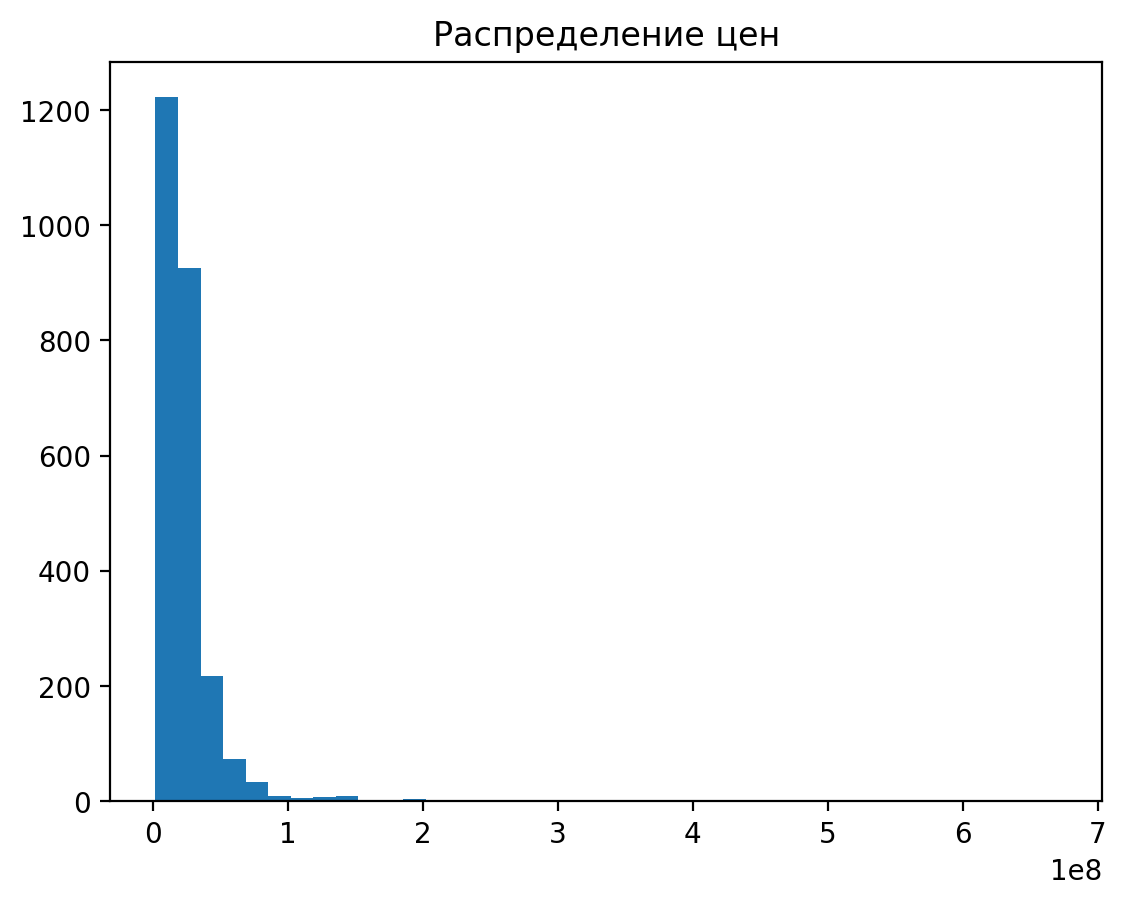

In [25]:
# Цена
fig = plt.figure()
plt.hist(df_clean["price"], bins=40)
plt.title("Распределение цен")
save_and_show(fig, "price.png")


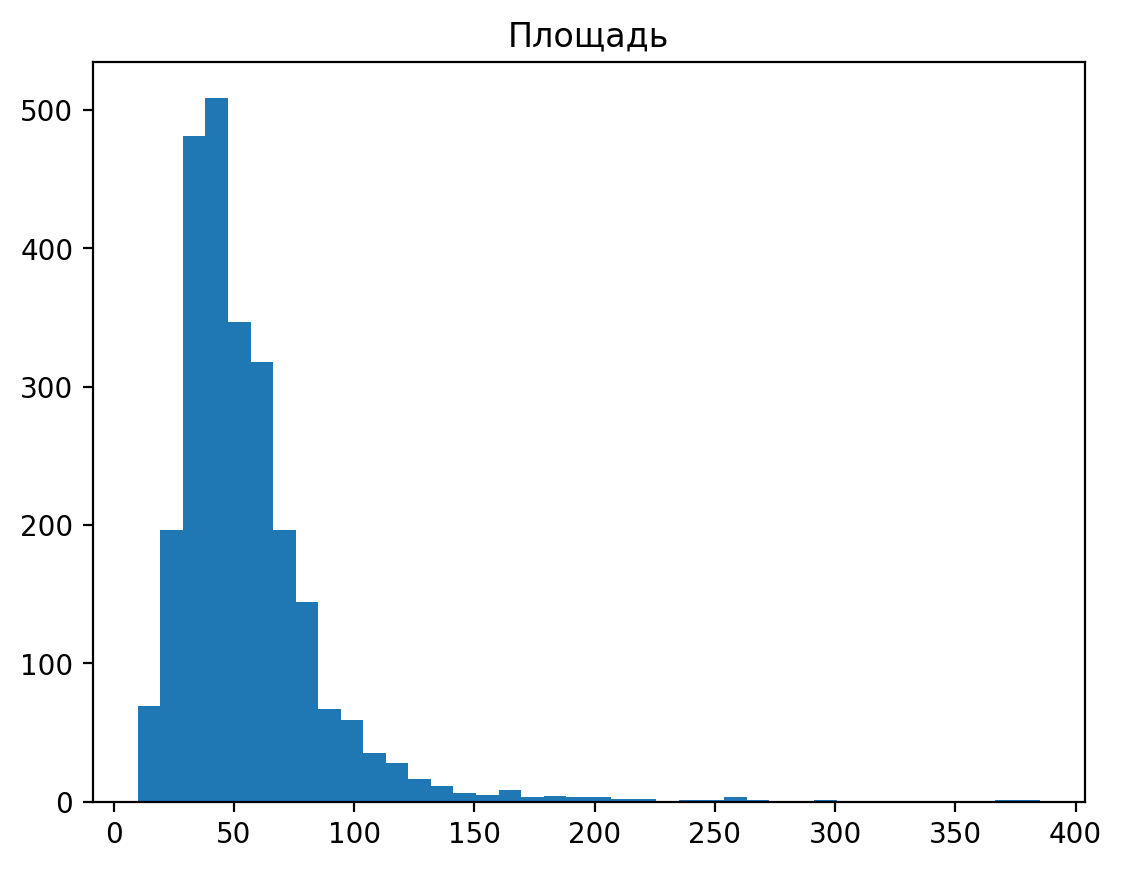

In [26]:
# Площадь
fig = plt.figure()
plt.hist(df_clean["area_total"], bins=40)
plt.title("Площадь")
save_and_show(fig, "area.png")


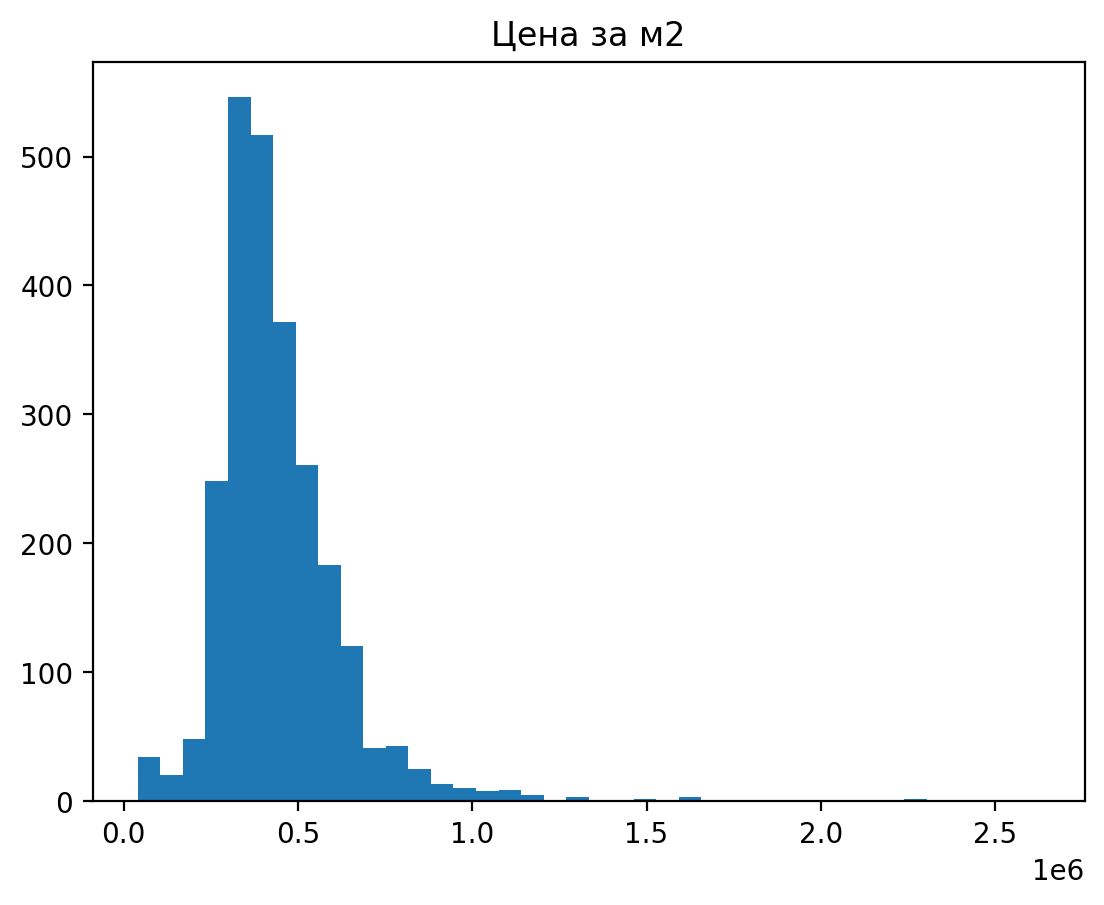

In [27]:
# Цена за м2
fig = plt.figure()
plt.hist(df_clean["price_per_m2"], bins=40)
plt.title("Цена за м2")
save_and_show(fig, "price_per_m2.png")


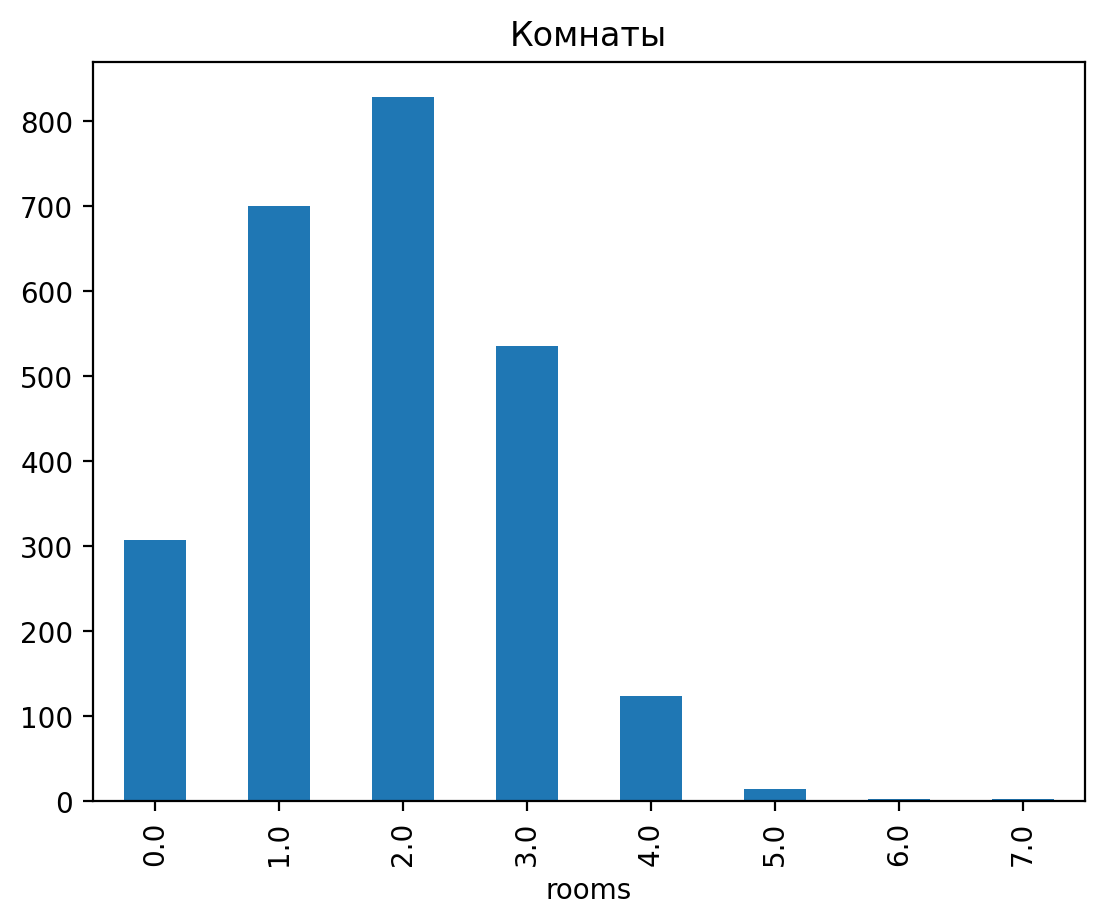

In [28]:
# Комнаты
fig = plt.figure()
df_clean["rooms"].value_counts().sort_index().plot(kind="bar")
plt.title("Комнаты")
save_and_show(fig, "rooms.png")

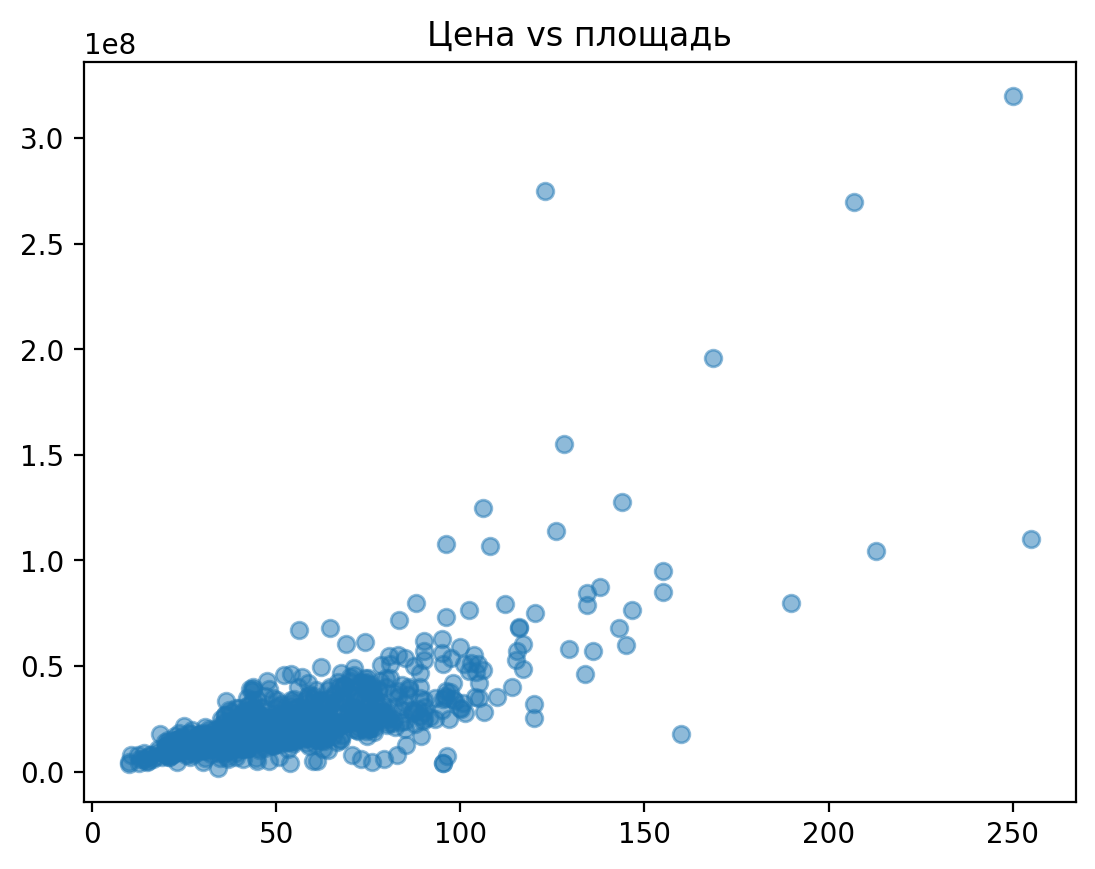

In [29]:
# Scatter
sample = df_clean.sample(min(1000, len(df_clean)))
fig = plt.figure()
plt.scatter(sample["area_total"], sample["price"], alpha=0.5)
plt.title("Цена vs площадь")
save_and_show(fig, "scatter.png")

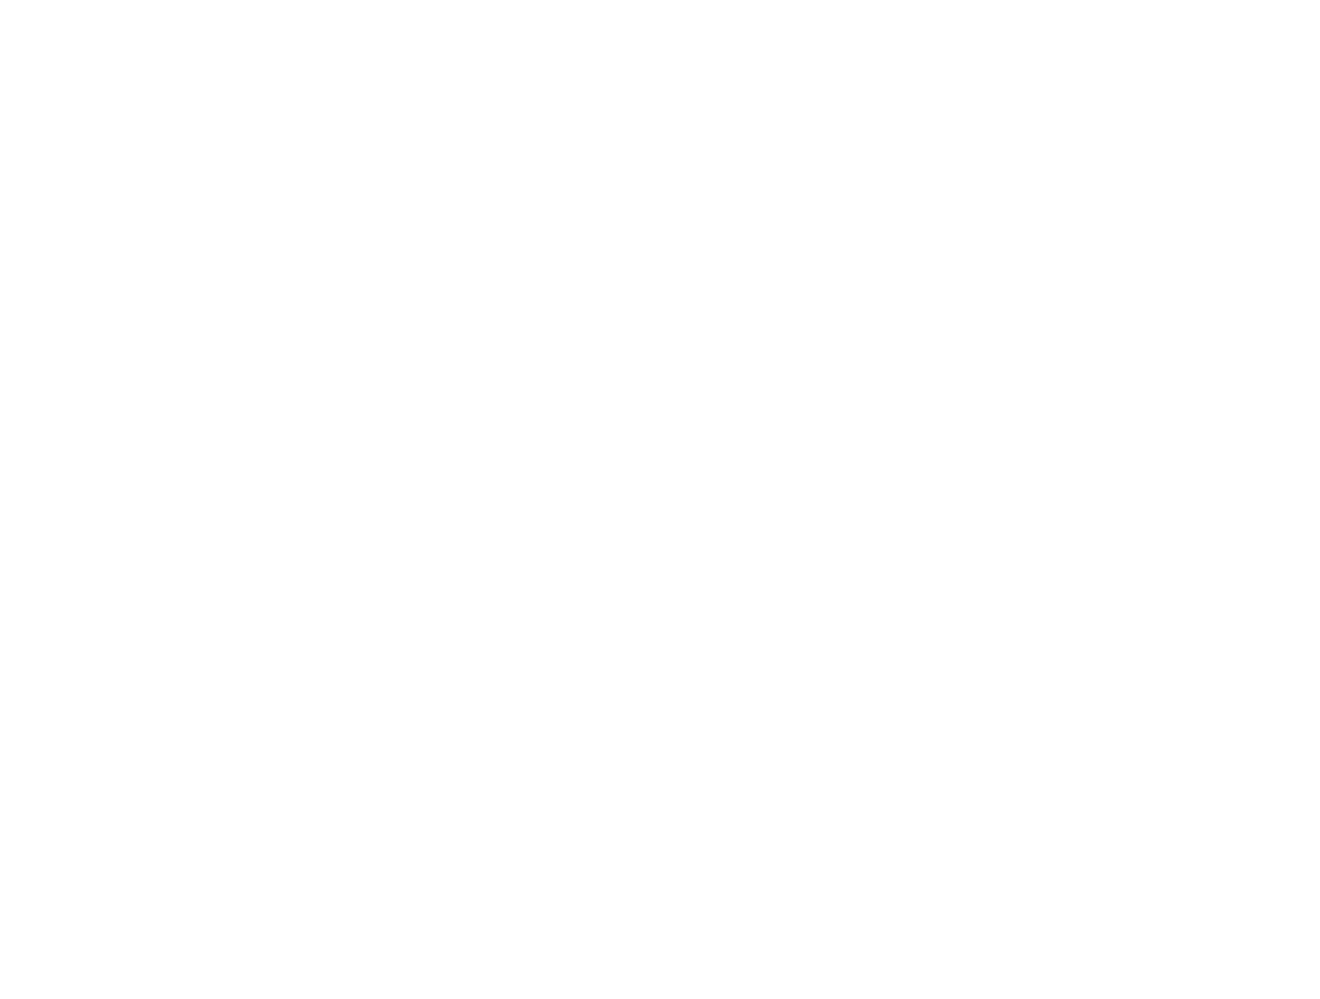

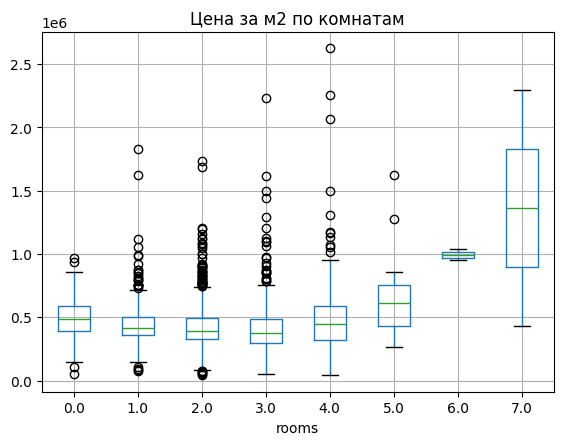

In [30]:
# Boxplot (ВАЖНО)
fig = plt.figure()
df_clean.boxplot(column="price_per_m2", by="rooms")
plt.title("Цена за м2 по комнатам")
plt.suptitle("")
save_and_show(fig, "boxplot.png")

In [31]:
print(df_clean.isna().sum())

print("\nТоп метро:")
display(df_clean["metro"].value_counts(dropna=False).head(20))

bad_addr = df_clean[
    df_clean["address"].astype(str).str.contains("посмотреть|фото|на карте", case=False, na=False)
][["address", "link"]]

print("\nПлохие адреса:")
display(bad_addr.head(20))
print("Осталось плохих адресов:", len(bad_addr))

bad_metro = df_clean[
    df_clean["metro"].astype(str).str.contains(r"^в$|^до метро$|^всего$|^на карте$", case=False, na=False, regex=True)
][["metro", "link"]]

print("\nПлохое метро:")
display(bad_metro.head(20))
print("Осталось плохих значений метро:", len(bad_metro))

source_group        0
price               0
area_total          0
kitchen_area       34
price_per_m2        0
rooms              10
floor              63
floors_total       63
address           185
metro             840
metro_walk_min    260
walls              67
walls_clean        67
link                0
address_raw         0
metro_raw         260
dtype: int64

Топ метро:


,count
metro,
NaN,840
Бульвар Рокоссовского,39
Аминьевская,34
Бабушкинская,28
Щелковская,28
Ботанический сад,28
Перово,24
Волгоградский проспект,22
Шелепиха,20



Плохие адреса:


,address,link


Осталось плохих адресов: 0

Плохое метро:


,metro,link


Осталось плохих значений метро: 0


In [32]:
print("Файлы в plots/:")
for p in sorted(PLOTS_DIR.iterdir()):
    print("-", p.name)

print("\nОчищенный CSV существует:", CLEAN_FILE.exists())

Файлы в plots/:
- area.png
- area_distribution.png
- boxplot.png
- price.png
- price_distribution.png
- price_per_m2.png
- price_per_m2_by_rooms.png
- price_per_m2_distribution.png
- price_vs_area.png
- readme.md
- rooms.png
- rooms_distribution.png
- scatter.png
- top_metro.png

Очищенный CSV существует: True


In [33]:
from google.colab import files
import shutil

# Архивируем папку с графиками
shutil.make_archive("plots", "zip", PLOTS_DIR)

# Скачиваем архив
files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
files.download(str(CLEAN_FILE))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>